# Global Food Trade Network Analysis: Trade Centrality and Producer Prices

## Overview

This notebook examines global trade patterns for five staple commodities from 2005 to 2024. Bilateral trade flows are represented as directed, weighted networks, with countries as nodes and trade relationships as edges.

The analysis looks at two sides of the trade network:

- **Supplier influence**: countries that occupy important positions in the global supply network.
- **Import hub centrality**: countries that receive goods from important suppliers and therefore occupy important positions on the demand side of the network.

The network results are also compared with producer prices for maize in 2022 to explore how international trade position relates to local agricultural prices.

## Data Preparation

The trade matrix contains import and export records as well as both quantity and value measures. For the network analysis, only **Export quantity** records measured in **tonnes** are used.


The analysis focuses on five staple commodities:

- Wheat
- Maize (corn)
- Rice
- Soya beans
- Barley


In [2]:
import os
from pathlib import Path
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

#Project paths

BASE_DIR = Path(file).resolve().parent if 'file' in locals() else Path.cwd()

PROJECT_ROOT = BASE_DIR.parent if BASE_DIR.name == "notebooks" else BASE_DIR

DATA_DIR = PROJECT_ROOT / "data" / "cleaned"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "historical_timelines"

matrix_path = DATA_DIR / "trade_matrix_cleaned.csv"
mirror_path = DATA_DIR / "mirror_exports_cleaned.csv"
prices_path = DATA_DIR / "producer_prices_cleaned.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Trade Data Preparation

The trade matrix contains several types of observations, including export value, export quantity, import value, and import quantity.

Because the network represents physical trade flows, the analysis uses only **export quantity measured in tonnes**. This prevents values in different units from being combined in the same network.

The mirror-export file is then used to fill gaps in reported exports. Where a recommended mirror-based value is available, it is used as the final trade weight.



In [3]:
# Load source data
matrix_df = pd.read_csv(matrix_path)
mirror_df = pd.read_csv(mirror_path)

print("Trade matrix shape:", matrix_df.shape)
print("Mirror export shape:", mirror_df.shape)



# Keep only export quantity observations measured in tonnes
matrix_df = matrix_df[
    (matrix_df["Element"] == "Export quantity") &
    (matrix_df["Unit"] == "t")
].copy()

print("Filtered trade matrix shape:", matrix_df.shape)
print("\nElements:")
print(matrix_df["Element"].value_counts())

print("\nUnits:")
print(matrix_df["Unit"].value_counts())


Trade matrix shape: (24719738, 11)
Mirror export shape: (28651, 11)
Filtered trade matrix shape: (6970218, 11)

Elements:
Element
Export quantity    6970218
Name: count, dtype: int64

Units:
Unit
t    6970218
Name: count, dtype: int64


## Filling Missing Export Records

The mirror-export dataset contains recommended export values for cases where direct exporter reporting is incomplete.

The `recommended_value` field is used as the final trade weight because it represents the cleaned value selected from direct and mirror reporting.


In [4]:

# Keep only export quantity observations from the mirror dataset
mirror_quantity = mirror_df[
    mirror_df["element"] == "Export quantity"
].copy()

# Check for duplicate country-item-year combinations
duplicate_count = mirror_quantity.duplicated(
    subset=["area_code", "item_code", "year"]
).sum()

print("Mirror export quantity rows:", len(mirror_quantity))
print("Duplicate area/item/year rows:", duplicate_count)

if duplicate_count > 0:
    raise ValueError(
        "Duplicate area_code/item_code/year combinations found in mirror data."
    )


Mirror export quantity rows: 14568
Duplicate area/item/year rows: 0


In [5]:

# Keep only the columns required for the merge
mirror_quantity = mirror_quantity[
    [
        "area_code",
        "item_code",
        "year",
        "recommended_value",
        "coverage_flag"
    ]
].copy()


In [6]:
# Merge mirror-based recommendations onto the direct export records
merged_df = pd.merge(
    matrix_df,
    mirror_quantity,
    left_on=[
        "Reporter Country Code",
        "Item Code",
        "Year"
    ],
    right_on=[
        "area_code",
        "item_code",
        "year"
    ],
    how="left"
)

# Use the recommended value where available
merged_df["final_weight"] = (
    merged_df["recommended_value"]
    .fillna(merged_df["Value"])
)

# Remove observations without usable trade weights or country names
merged_df = merged_df.dropna(
    subset=[
        "final_weight",
        "Reporter Countries",
        "Partner Countries"
    ]
)

# Keep only positive trade flows
merged_df = merged_df[merged_df["final_weight"] > 0].copy()

print("Merged trade rows:", len(merged_df))
print("Years:", merged_df["Year"].min(), "to", merged_df["Year"].max())


Merged trade rows: 6337597
Years: 2005 to 2024


## Staple Commodities

The analysis focuses on five staple commodities so that the historical comparison remains consistent across the study period.


In [7]:
core_staples = [
    "Wheat",
    "Maize (corn)",
    "Rice",
    "Soya beans",
    "Barley"
]

merged_df = merged_df[
    merged_df["Item"].isin(core_staples)
].copy()

print("Commodities retained:")
print(sorted(merged_df["Item"].unique()))

print("\nRows by commodity:")
print(merged_df["Item"].value_counts())


## Data Checks: Before constructing the networks, a few basic checks are performed to make sure the --
# -- filtered dataset contains the expected years, commodities, and trade weights.


print("Years covered:", merged_df["Year"].min(), "to", merged_df["Year"].max())

print("\nCommodity-year combinations:")
print(
    merged_df.groupby(["Item", "Year"]).size()
    .groupby(level=0)
    .count()
)

print("\nMissing final weights:", merged_df["final_weight"].isna().sum())
print("Non-positive final weights:", (merged_df["final_weight"] <= 0).sum())


Commodities retained:
['Barley', 'Maize (corn)', 'Rice', 'Soya beans', 'Wheat']

Rows by commodity:
Item
Maize (corn)    29509
Wheat           22931
Soya beans      16048
Barley          13398
Rice             8128
Name: count, dtype: int64
Years covered: 2005 to 2024

Commodity-year combinations:
Item
Barley          20
Maize (corn)    20
Rice            20
Soya beans      20
Wheat           20
dtype: int64

Missing final weights: 0
Non-positive final weights: 0


# Maize Trade Network — 2022

## PageRank and Network Direction

The trade network is directed from the exporting country to the importing country.

Applying PageRank to the original network gives greater importance to countries that receive trade from important parts of the network. This makes it useful for identifying major **import hubs**.

To examine the supplier side, the network is reversed before calculating PageRank. This allows countries that supply important markets to receive higher supplier-influence scores.

Two measures are therefore retained:

- **Supplier Influence**: PageRank calculated on the reversed network.
- **Import Hub Score**: PageRank calculated on the original network.

The analysis also reports the number of export and import connections for each country.


In [8]:
maize_2022 = merged_df[
    (merged_df["Item"] == "Maize (corn)") &
    (merged_df["Year"] == 2022)
].copy()

# Aggregate all observations between the same exporter and importer
maize_edges = (
    maize_2022
    .groupby(
        ["Reporter Countries", "Partner Countries"],
        as_index=False
    )["final_weight"]
    .sum()
)

print("Maize trade observations:", len(maize_2022))
print("Unique bilateral trade links:", len(maize_edges))


Maize trade observations: 1715
Unique bilateral trade links: 1715


In [9]:

G_maize = nx.from_pandas_edgelist(
    maize_edges,
    source="Reporter Countries",
    target="Partner Countries",
    edge_attr="final_weight",
    create_using=nx.DiGraph()
)

print("Countries in network:", G_maize.number_of_nodes())
print("Trade links:", G_maize.number_of_edges())


Countries in network: 191
Trade links: 1715


In [10]:
# Supplier-side PageRank
supplier_pagerank = nx.pagerank(
    G_maize.reverse(),
    weight="final_weight"
)

# Import-hub PageRank
importer_pagerank = nx.pagerank(
    G_maize,
    weight="final_weight"
)

# Number of export and import connections
out_degree = dict(G_maize.out_degree())
in_degree = dict(G_maize.in_degree())

network_report = pd.DataFrame({
    "Supplier Influence": pd.Series(supplier_pagerank),
    "Import Hub Score": pd.Series(importer_pagerank),
    "Export Connections": pd.Series(out_degree),
    "Import Connections": pd.Series(in_degree)
})

network_report = network_report.sort_values(
    "Supplier Influence",
    ascending=False
)

network_report.head(15)



,Supplier Influence,Import Hub Score,Export Connections,Import Connections
United States of America,0.282813,0.011987,104,28
Brazil,0.208523,0.005921,87,11
Argentina,0.178509,0.005016,84,10
France,0.038027,0.013116,85,32
South Africa,0.034543,0.006369,94,13
Ukraine,0.023435,0.005340,56,13
India,0.023266,0.004742,71,10
Romania,0.020004,0.006112,53,17
Canada,0.010250,0.007590,24,16
Hungary,0.008271,0.006774,52,21


## Leading Maize Suppliers

The table below ranks countries by supplier influence in the 2022 maize network.

A high supplier-influence score indicates that a country occupies an important position on the supplier side of the network. This should not be interpreted as a simple ranking of export volume, since PageRank also considers the importance of the markets connected to each supplier.


In [12]:
supplier_ranking = (
    network_report
    .sort_values("Supplier Influence", ascending=False)
    .head(15)
)

supplier_ranking


,Supplier Influence,Import Hub Score,Export Connections,Import Connections
United States of America,0.282813,0.011987,104,28
Brazil,0.208523,0.005921,87,11
Argentina,0.178509,0.005016,84,10
France,0.038027,0.013116,85,32
South Africa,0.034543,0.006369,94,13
Ukraine,0.023435,0.005340,56,13
India,0.023266,0.004742,71,10
Romania,0.020004,0.006112,53,17
Canada,0.010250,0.007590,24,16
Hungary,0.008271,0.006774,52,21


## Global Maize Trade Backbone

The chart below shows the 50 largest bilateral maize trade links in 2022.

The arrows indicate the direction of trade from exporter to importer. Node size represents supplier influence within this reduced network.

The purpose of the chart is to highlight the main trade corridors and the countries that occupy important positions within them.


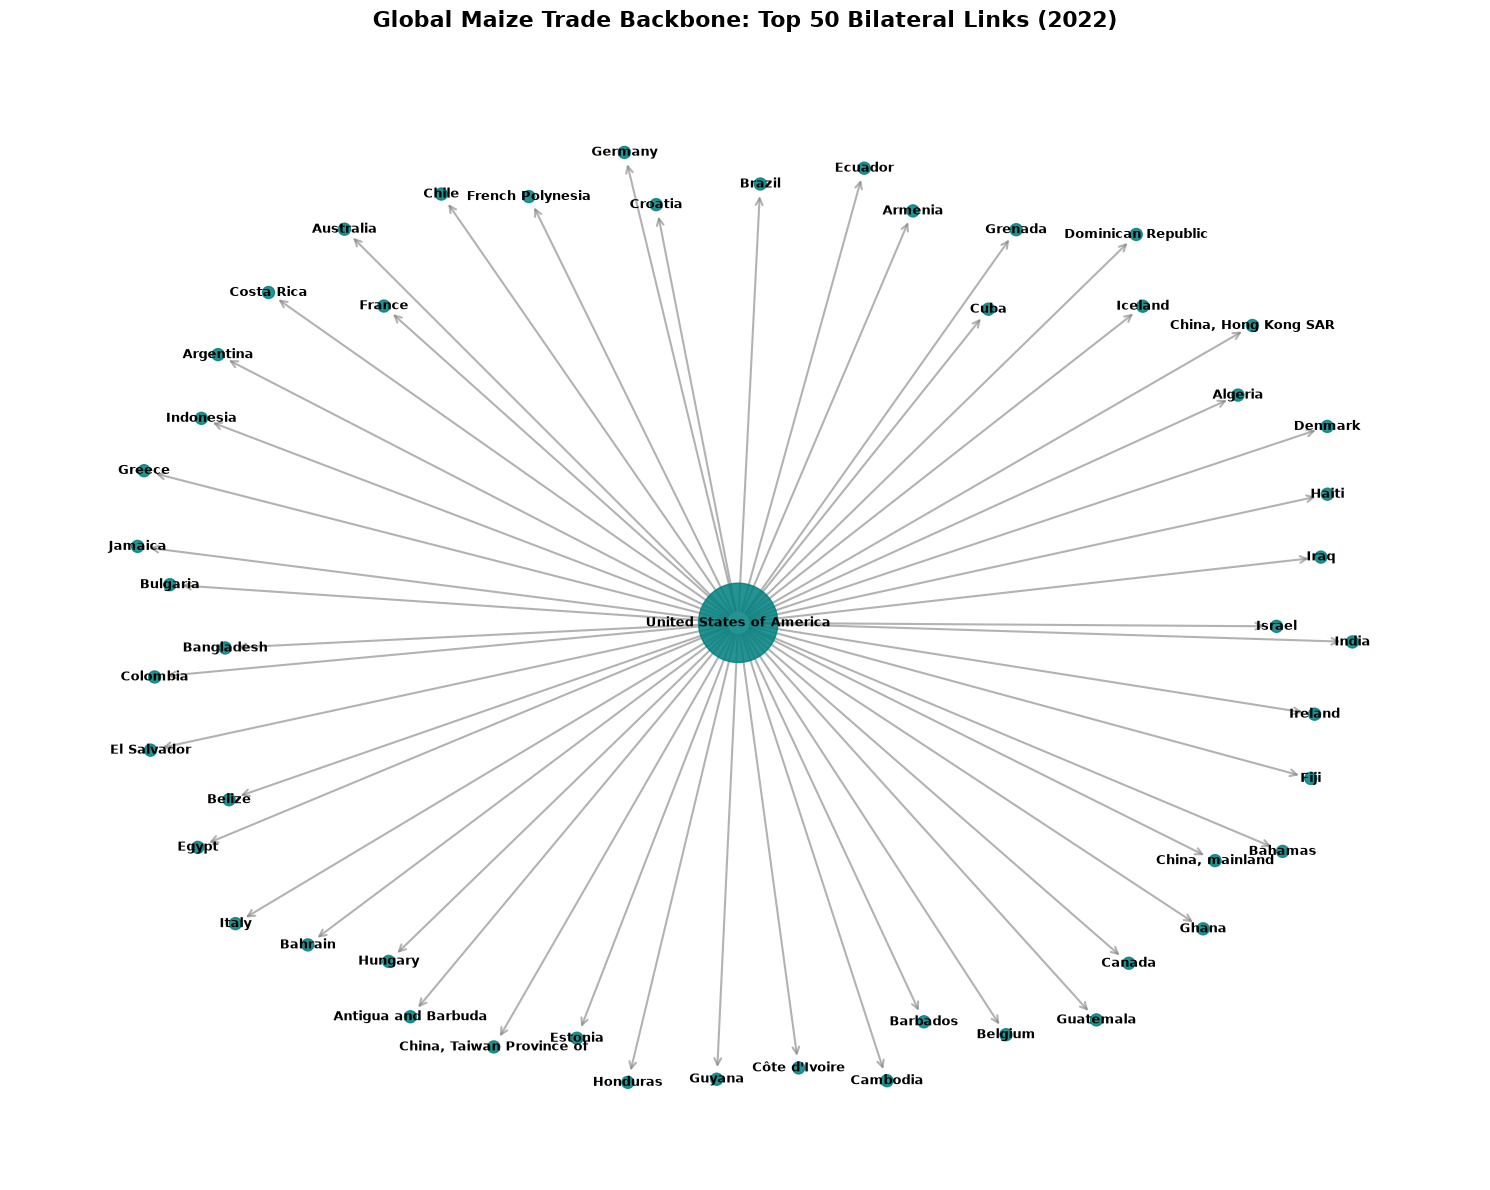

In [13]:
top_edges = maize_edges.nlargest(
    50,
    "final_weight"
)

G_sub = nx.from_pandas_edgelist(
    top_edges,
    source="Reporter Countries",
    target="Partner Countries",
    edge_attr="final_weight",
    create_using=nx.DiGraph()
)

# Calculate supplier influence within the displayed sub-network
sub_pagerank = nx.pagerank(
    G_sub.reverse(),
    weight="final_weight"
)

node_sizes = [
    sub_pagerank[node] * 7000
    for node in G_sub.nodes()
]

fig, ax = plt.subplots(
    figsize=(15, 12),
    dpi=100
)

ax.set_title(
    "Global Maize Trade Backbone: Top 50 Bilateral Links (2022)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

pos = nx.spring_layout(
    G_sub,
    k=0.5,
    seed=42
)

nx.draw_networkx_nodes(
    G_sub,
    pos,
    node_size=node_sizes,
    node_color="teal",
    alpha=0.85,
    ax=ax
)

nx.draw_networkx_labels(
    G_sub,
    pos,
    font_size=9,
    font_weight="bold",
    ax=ax
)

nx.draw_networkx_edges(
    G_sub,
    pos,
    arrowstyle="->",
    arrowsize=12,
    edge_color="gray",
    alpha=0.6,
    width=1.5,
    ax=ax
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "maize_trade_backbone_2022.png",
    bbox_inches="tight"
)

plt.show()



# Producer Prices and Trade Position

## Maize Producer Prices — 2022

Producer prices are compared with supplier influence for maize in 2022.

It shows how producer price levels vary across countries with different positions in the international maize trade network.

The relationship should not be interpreted as causal. A country's producer price can also be affected by domestic production, input costs, exchange rates, policies, weather, and other market conditions.



In [14]:
prices_df = pd.read_csv(prices_path)

prices_filtered = prices_df[
    (prices_df["Item"] == "Maize (corn)") &
    (prices_df["Year"] == 2022) &
    (prices_df["Element"] == "Producer Price (USD/tonne)")
][
    ["Area", "Value"]
].rename(
    columns={
        "Area": "Country",
        "Value": "Producer Price (USD/tonne)"
    }
)

print("Producer price observations:", len(prices_filtered))
prices_filtered.head()


Producer price observations: 31


,Country,Producer Price (USD/tonne)
7139,Austria,310.6
12655,Brazil,243.8
15929,Canada,251.0
18931,Chile,350.4
23308,"China, mainland",378.1


In [16]:
nexus_df = pd.merge(
    network_report.reset_index().rename(
        columns={"index": "Country"}
    ),
    prices_filtered,
    on="Country",
    how="inner"
)

print("Countries included in price-network comparison:", len(nexus_df))

nexus_df.head()



Countries included in price-network comparison: 31


,Country,Supplier Influence,Import Hub Score,Export Connections,Import Connections,Producer Price (USD/tonne)
0,United States of America,0.282813,0.011987,104,28,263.8
1,Brazil,0.208523,0.005921,87,11,243.8
2,France,0.038027,0.013116,85,32,329.2
3,South Africa,0.034543,0.006369,94,13,246.8
4,Ukraine,0.023435,0.005340,56,13,202.7


## The Price-Centrality Comparison

The scatter plot compares supplier influence with maize producer prices.

Each point represents a country. Countries further along the horizontal axis have greater supplier influence in the trade network, while higher positions on the vertical axis represent higher producer prices.

Point size reflects the number of export connections.



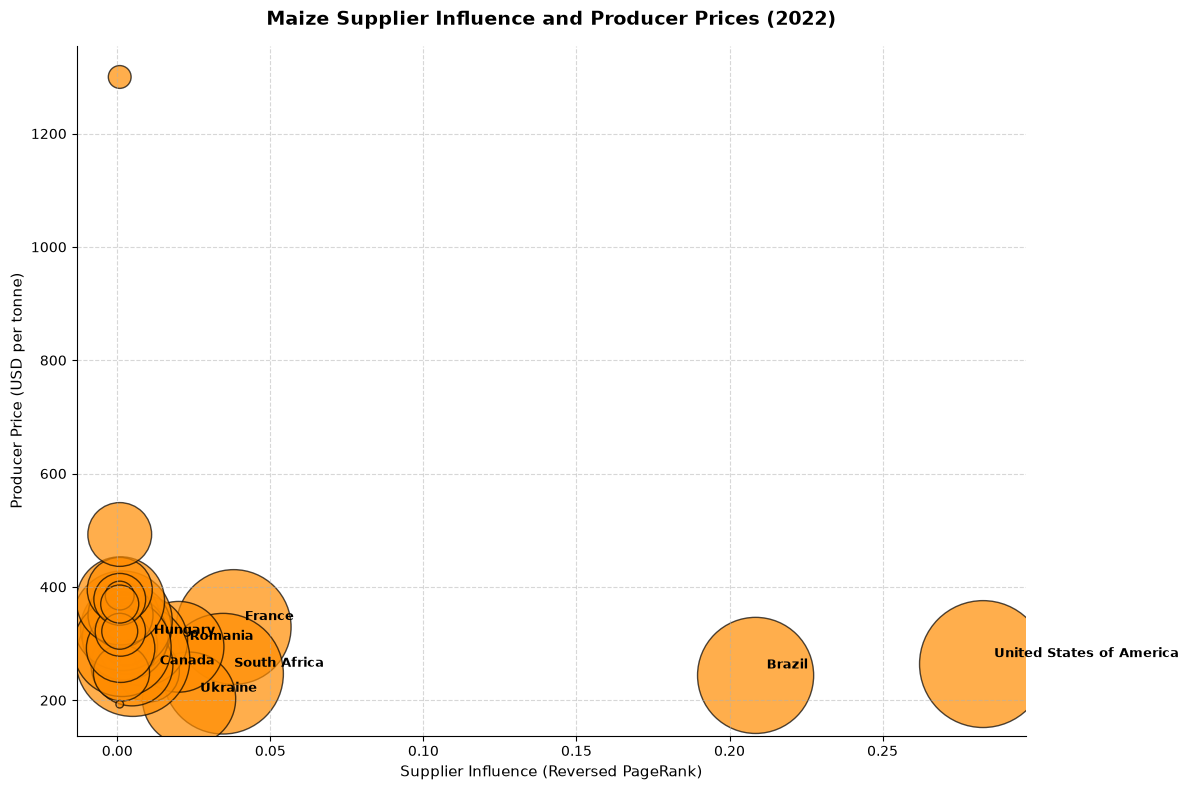

In [17]:
fig, ax = plt.subplots(
    figsize=(12, 8),
    dpi=100
)

ax.set_title(
    "Maize Supplier Influence and Producer Prices (2022)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

x = nexus_df["Supplier Influence"]
y = nexus_df["Producer Price (USD/tonne)"]
sizes = nexus_df["Export Connections"] * 80 + 30

ax.scatter(
    x,
    y,
    s=sizes,
    c="darkorange",
    alpha=0.7,
    edgecolors="black",
    linewidth=1
)

# Label the countries with the highest supplier influence
labels_df = nexus_df.nlargest(
    8,
    "Supplier Influence"
)

for _, row in labels_df.iterrows():
    ax.annotate(
        row["Country"],
        (
            row["Supplier Influence"],
            row["Producer Price (USD/tonne)"]
        ),
        textcoords="offset points",
        xytext=(8, 5),
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

ax.set_xlabel(
    "Supplier Influence (Reversed PageRank)",
    fontsize=11
)

ax.set_ylabel(
    "Producer Price (USD per tonne)",
    fontsize=11
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.5
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "maize_price_centrality_nexus_2022.png",
    bbox_inches="tight"
)

plt.show()


# Historical Trade Networks — 2005–2024

## Tracking Supplier Influence Over Time

The same network procedure is applied to each of the five commodities for every year from 2005 to 2024.

For each commodity-year combination, bilateral trade flows are aggregated into a directed network. Supplier-side PageRank is then calculated on the reversed network.

This produces a yearly measure of supplier influence that can be used to track how the position of major exporters changes over time.

PageRank is normalized within each network, the historical analysis focuses on changes within each commodity over time.


In [18]:

master_records = []

for (item_name, year_val), group_df in merged_df.groupby(
    ["Item", "Year"]
):
    
    # Aggregate bilateral trade flows first
    edges = (
        group_df
        .groupby(
            ["Reporter Countries", "Partner Countries"],
            as_index=False
        )["final_weight"]
        .sum()
    )
    
    # Skip very small networks
    if len(edges) < 5:
        continue
    
    G = nx.from_pandas_edgelist(
        edges,
        source="Reporter Countries",
        target="Partner Countries",
        edge_attr="final_weight",
        create_using=nx.DiGraph()
    )
    
    if G.number_of_nodes() < 2:
        continue
    
    supplier_pr = nx.pagerank(
        G.reverse(),
        weight="final_weight"
    )
    
    for country, score in supplier_pr.items():
        master_records.append({
            "Commodity": item_name,
            "Year": int(year_val),
            "Country": country,
            "Supplier_Influence": score
        })

historical_metrics_df = pd.DataFrame(master_records)

historical_metrics_path = (
    DATA_DIR / "historical_trade_network_metrics.csv"
)

historical_metrics_df.to_csv(
    historical_metrics_path,
    index=False
)

print(
    "Historical metric rows:",
    len(historical_metrics_df)
)

print(
    "Saved to:",
    historical_metrics_path
)



Historical metric rows: 15651
Saved to: c:\Users\HP\FoodMatrix_Datathon\data\cleaned\historical_trade_network_metrics.csv


## Major Supplier Trajectories

For each commodity, the countries with the highest average supplier influence across the study period are selected for the timeline.

The resulting charts show how their supplier influence changes from year to year. These rankings are based on average PageRank over the 2005–2024 period and are used only to select the countries displayed in each chart.


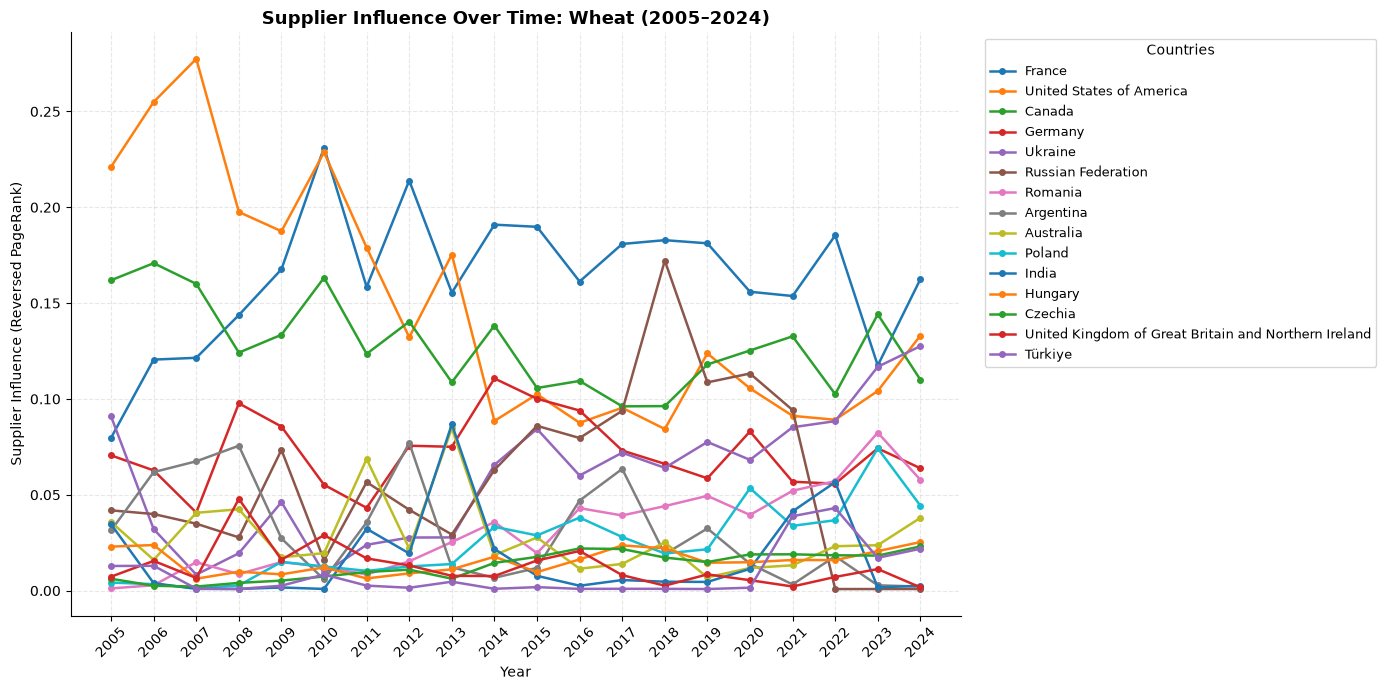

Saved: c:\Users\HP\FoodMatrix_Datathon\notebooks\historical_timelines\wheat_top15_timeline.png


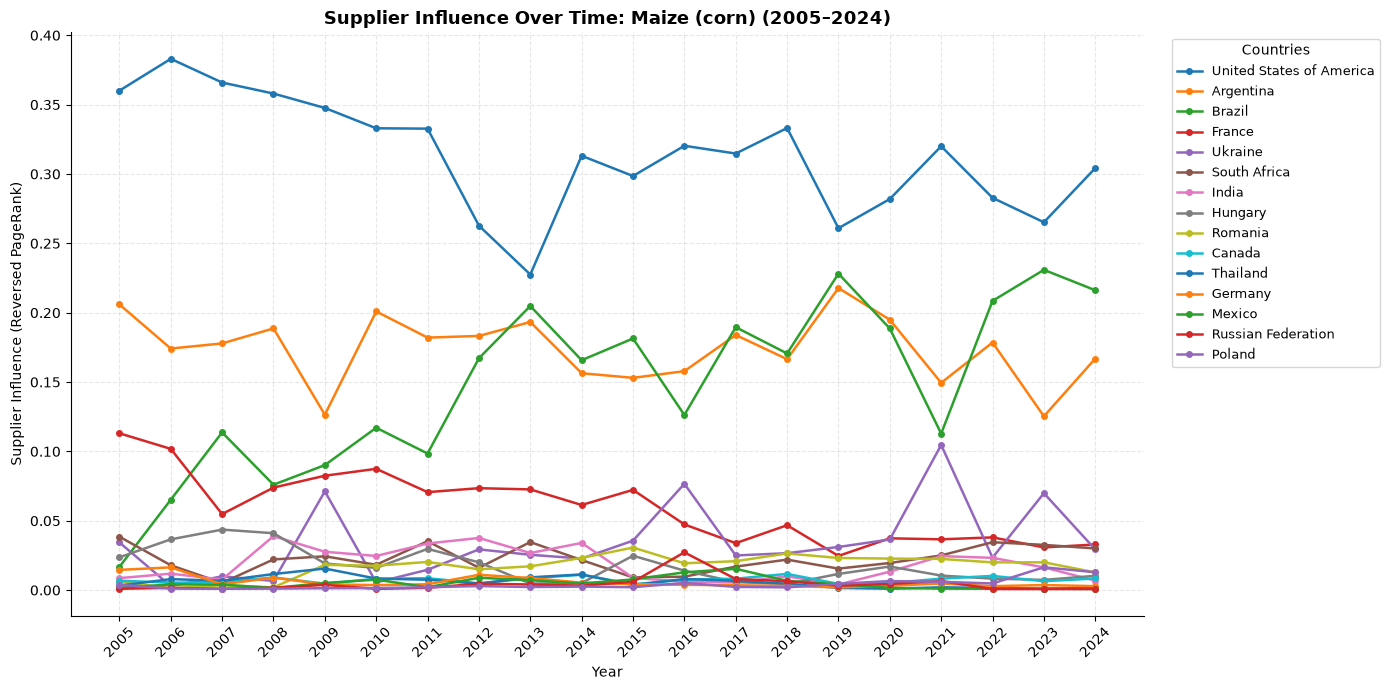

Saved: c:\Users\HP\FoodMatrix_Datathon\notebooks\historical_timelines\maize_corn_top15_timeline.png


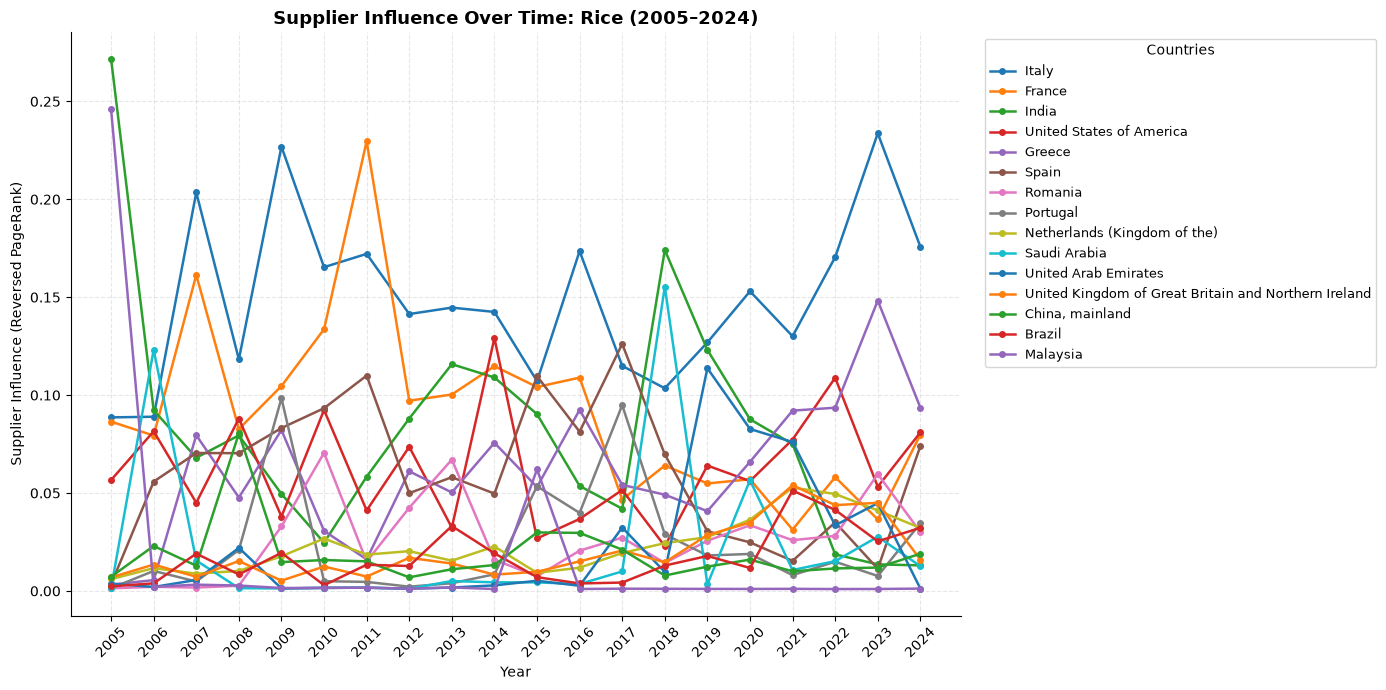

Saved: c:\Users\HP\FoodMatrix_Datathon\notebooks\historical_timelines\rice_top15_timeline.png


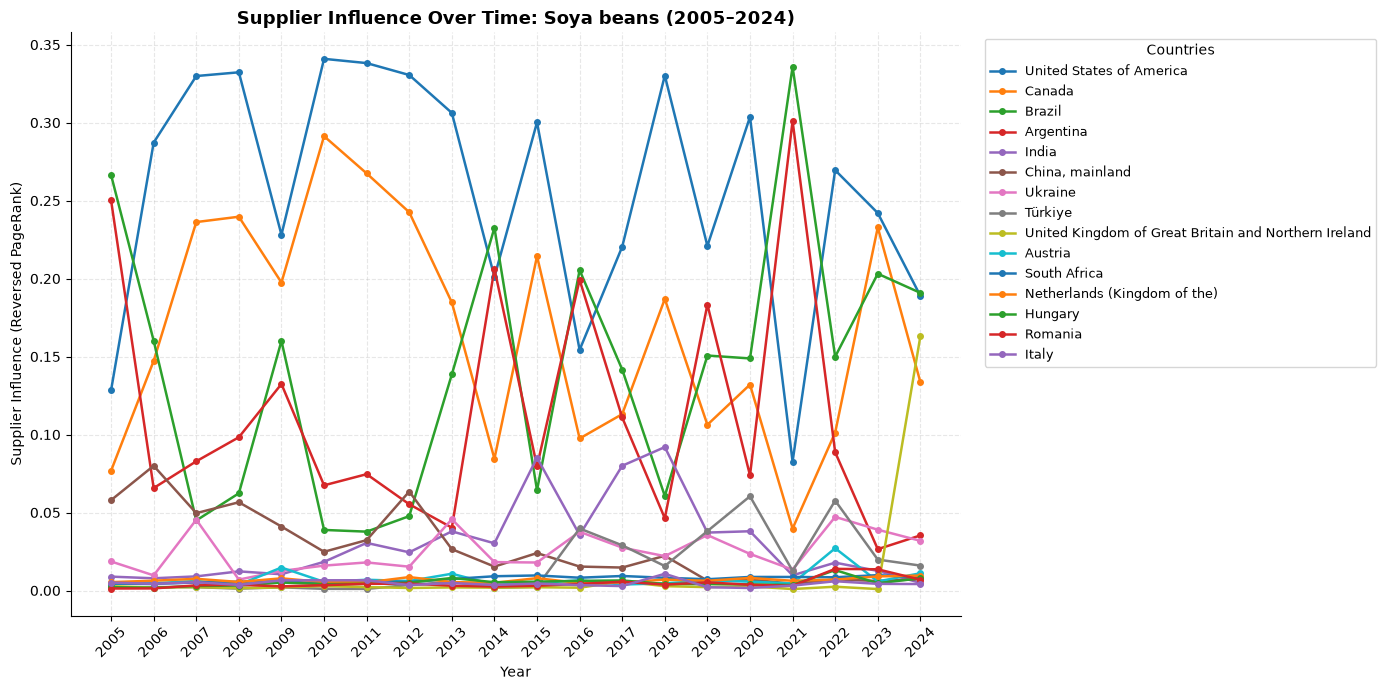

Saved: c:\Users\HP\FoodMatrix_Datathon\notebooks\historical_timelines\soya_beans_top15_timeline.png


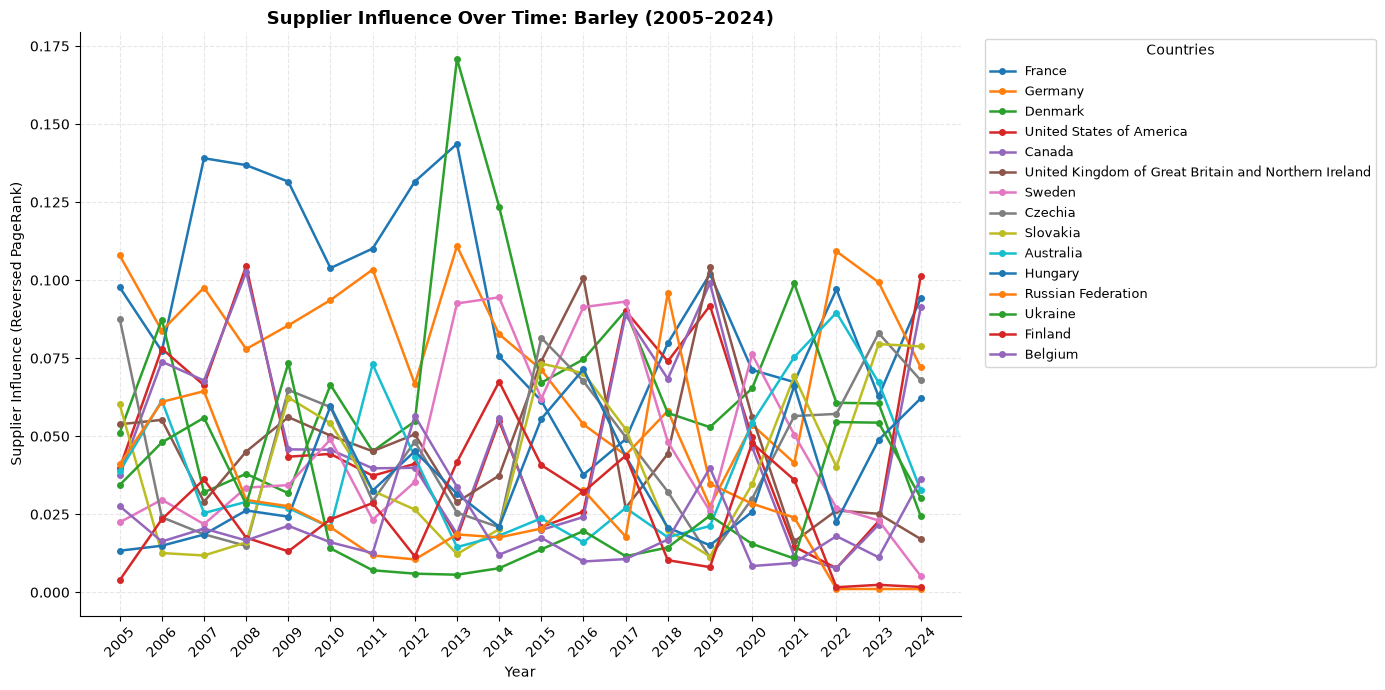

Saved: c:\Users\HP\FoodMatrix_Datathon\notebooks\historical_timelines\barley_top15_timeline.png


In [19]:

for commodity_name in core_staples:

    crop_history = historical_metrics_df[
        historical_metrics_df["Commodity"] == commodity_name
    ].copy()

    if crop_history.empty:
        print(f"No historical data available for {commodity_name}")
        continue

    # Select countries with the highest average supplier influence
    top_anchors = (
        crop_history
        .groupby("Country")["Supplier_Influence"]
        .mean()
        .nlargest(15)
        .index
        .tolist()
    )

    crop_timeline_df = crop_history[
        crop_history["Country"].isin(top_anchors)
    ].copy()

    fig, ax = plt.subplots(
        figsize=(14, 7),
        dpi=100
    )

    ax.set_title(
        f"Supplier Influence Over Time: {commodity_name} (2005–2024)",
        fontsize=13,
        fontweight="bold"
    )

    for country in top_anchors:

        country_data = (
            crop_timeline_df[
                crop_timeline_df["Country"] == country
            ]
            .sort_values("Year")
        )

        if not country_data.empty:
            ax.plot(
                country_data["Year"],
                country_data["Supplier_Influence"],
                marker="o",
                markersize=4,
                linewidth=1.8,
                label=country
            )

    ax.set_xlabel("Year")
    ax.set_ylabel(
        "Supplier Influence (Reversed PageRank)"
    )

    ax.set_xticks(
        sorted(crop_timeline_df["Year"].unique())
    )

    ax.tick_params(
        axis="x",
        rotation=45
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.3
    )

    ax.legend(
        title="Countries",
        fontsize=9,
        loc="upper left",
        bbox_to_anchor=(1.02, 1)
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    safe_name = (
        commodity_name
        .lower()
        .replace(" ", "_")
        .replace(",", "")
        .replace("(", "")
        .replace(")", "")
    )

    output_path = (
        OUTPUT_DIR /
        f"{safe_name}_top15_timeline.png"
    )

    plt.savefig(
        output_path,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"Saved: {output_path}")



# Export Concentration Across Commodities

## Measuring Supplier Concentration

PageRank is useful for identifying important countries within an individual trade network, but its values are normalized within each network. It is therefore not suitable for comparing the overall scale or concentration of different commodities by simply summing PageRank scores.

To compare the structure of the five commodity markets, the analysis uses the **Herfindahl–Hirschman Index (HHI)** based on exporter shares.

For each commodity and year, we square each country's export market share and sum them together to calculate the HHI score (where s_i is the export share of country i).

A higher HHI indicates that exports are concentrated among fewer suppliers, while a lower value indicates a more distributed supplier base.


In [20]:

# Calculate total export quantity by commodity, year, and exporter
exporter_totals = (
    merged_df
    .groupby(
        [
            "Item",
            "Year",
            "Reporter Countries"
        ],
        as_index=False
    )["final_weight"]
    .sum()
    .rename(
        columns={
            "final_weight": "Exporter_Quantity"
        }
    )
)

# Total exports for each commodity-year
commodity_totals = (
    exporter_totals
    .groupby(
        ["Item", "Year"],
        as_index=False
    )["Exporter_Quantity"]
    .sum()
    .rename(
        columns={
            "Exporter_Quantity": "Total_Exports"
        }
    )
)

# Calculate exporter shares
hhi_df = exporter_totals.merge(
    commodity_totals,
    on=["Item", "Year"],
    how="left"
)

hhi_df["Export_Share"] = (
    hhi_df["Exporter_Quantity"] /
    hhi_df["Total_Exports"]
)

# HHI
commodity_hhi = (
    hhi_df
    .assign(
        Share_Squared=lambda x: x["Export_Share"] ** 2
    )
    .groupby(
        ["Item", "Year"],
        as_index=False
    )["Share_Squared"]
    .sum()
    .rename(
        columns={
            "Share_Squared": "Exporter_HHI"
        }
    )
)

commodity_hhi


,Item,Year,Exporter_HHI
0,Barley,2005,0.119853
1,Barley,2006,0.131481
2,Barley,2007,0.110150
3,Barley,2008,0.130884
4,Barley,2009,0.137727
...,...,...,...
95,Wheat,2020,0.159796
96,Wheat,2021,0.129412
97,Wheat,2022,0.127611
98,Wheat,2023,0.136860



## Overall Export Concentration

The table below summarizes the average exporter concentration for each commodity across the 2005–2024 study period.

This is a separate measure from supplier PageRank. HHI describes how concentrated export quantities are among countries, while PageRank describes structural position within the trade network.


In [21]:

hhi_summary = (
    commodity_hhi
    .groupby("Item")["Exporter_HHI"]
    .agg(
        Mean_HHI="mean",
        Minimum_HHI="min",
        Maximum_HHI="max"
    )
    .sort_values(
        "Mean_HHI",
        ascending=False
    )
)

hhi_summary


,Mean_HHI,Minimum_HHI,Maximum_HHI
Item,,,
Rice,0.565751,0.328348,0.869564
Soya beans,0.386919,0.326532,0.481404
Maize (corn),0.339290,0.197540,0.632593
Wheat,0.157106,0.122427,0.237826
Barley,0.121523,0.105919,0.147395


## Export Concentration Over Time

The following chart tracks exporter concentration for the five staple commodities from 2005 to 2024.

Changes in HHI show whether the supplier base became more concentrated or more distributed over the study period.


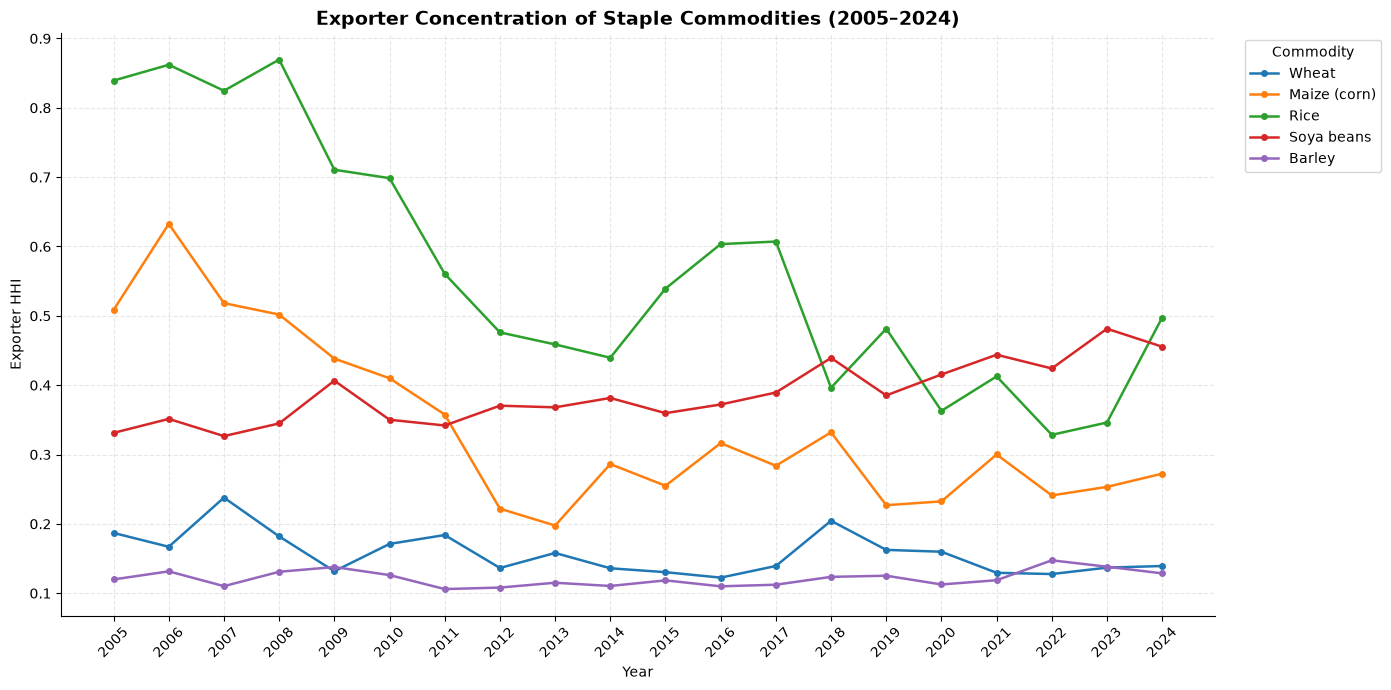

In [22]:
fig, ax = plt.subplots(
    figsize=(14, 7),
    dpi=100
)

for commodity_name in core_staples:

    commodity_data = commodity_hhi[
        commodity_hhi["Item"] == commodity_name
    ].sort_values("Year")

    if not commodity_data.empty:
        ax.plot(
            commodity_data["Year"],
            commodity_data["Exporter_HHI"],
            marker="o",
            markersize=4,
            linewidth=1.8,
            label=commodity_name
        )

ax.set_title(
    "Exporter Concentration of Staple Commodities (2005–2024)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Exporter HHI")

ax.set_xticks(
    sorted(commodity_hhi["Year"].unique())
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Commodity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "commodity_exporter_hhi_2005_2024.png",
    bbox_inches="tight"
)

plt.show()


### Global Trade Network Backbones (2005–2024 Cumulative)

The backbone charts show the main trade corridors that remained active over the 20-year study period. For each commodity, the networks are constructed using the 50 strongest bilateral export links, highlighting the countries and trade routes that played the most consistent roles in international supply.

- Node size: Represents a country’s total degree, or the number of active bilateral trade connections within the commodity network.
- Directed edges: Arrows show the direction of trade, running from exporting countries to their destination markets.




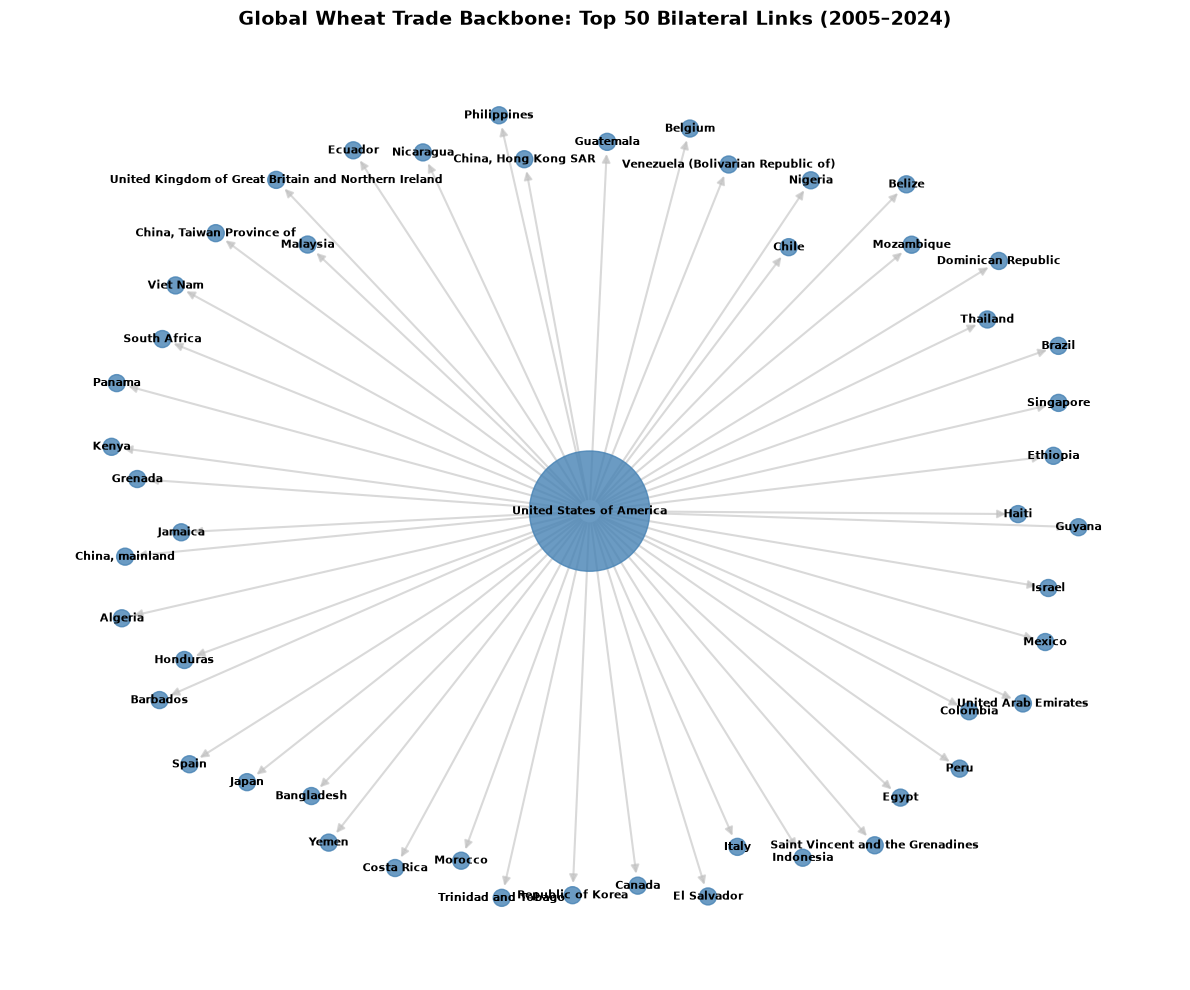

Saved: wheat_trade_backbone_2005_2024.png


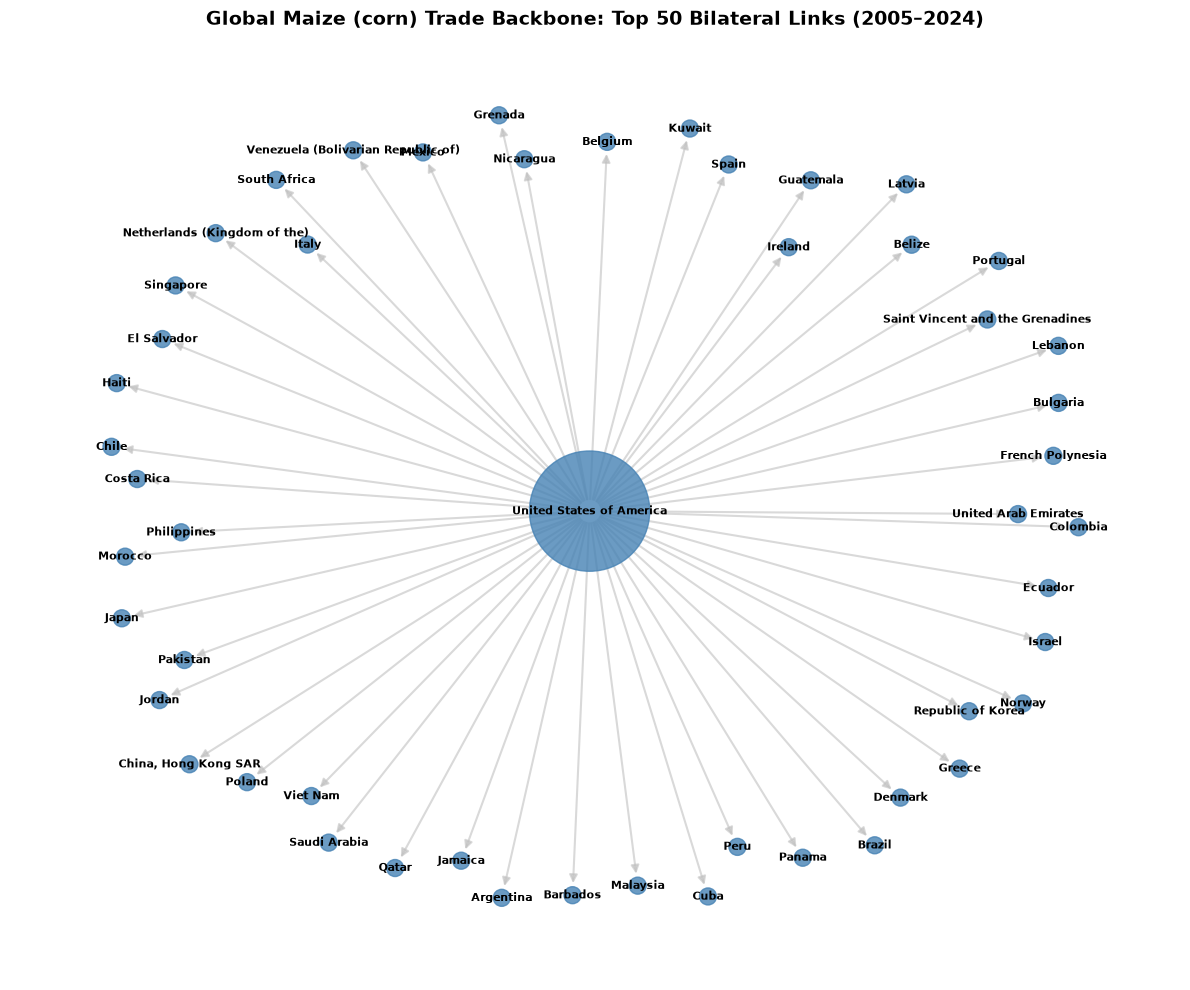

Saved: maize_corn_trade_backbone_2005_2024.png


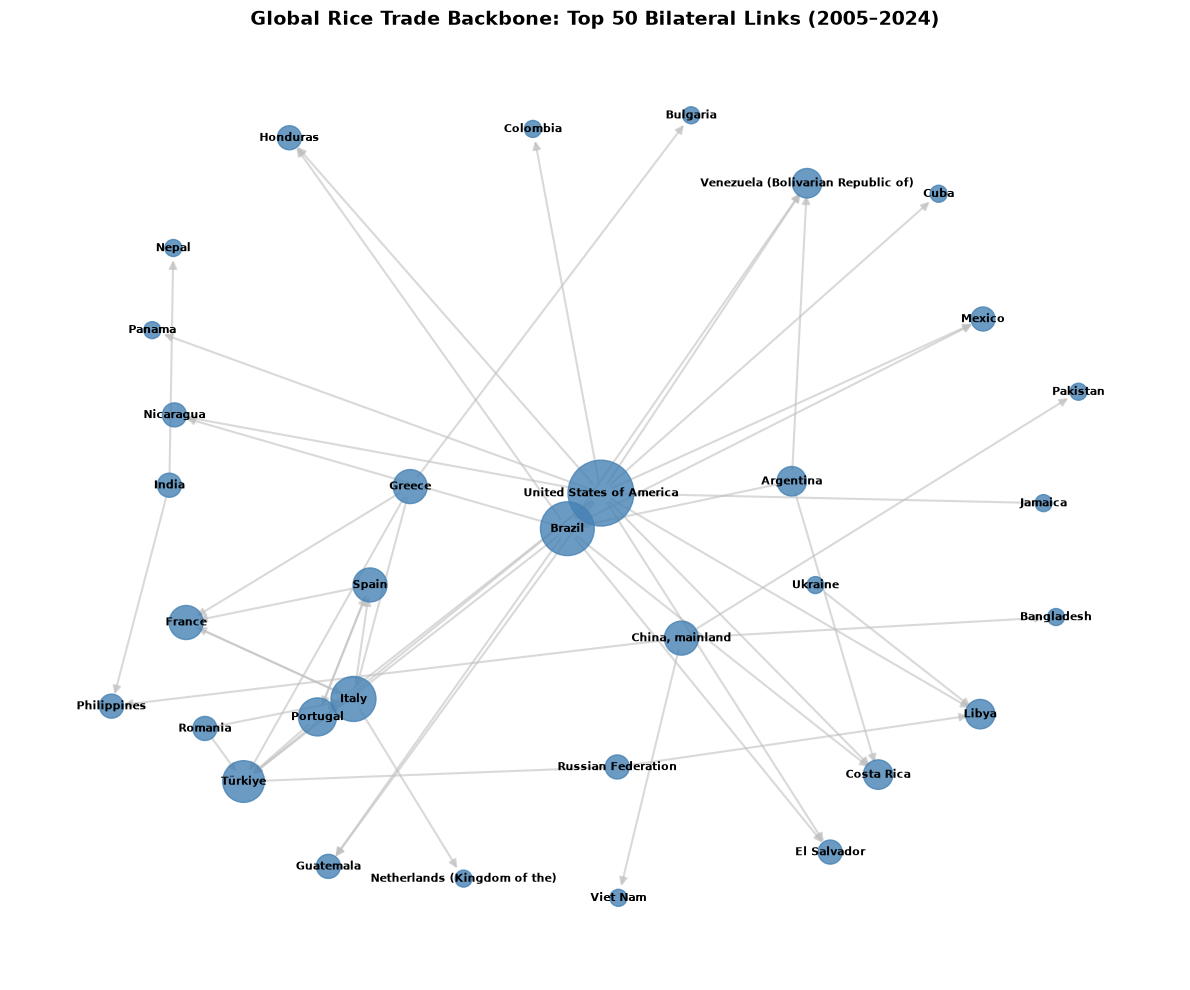

Saved: rice_trade_backbone_2005_2024.png


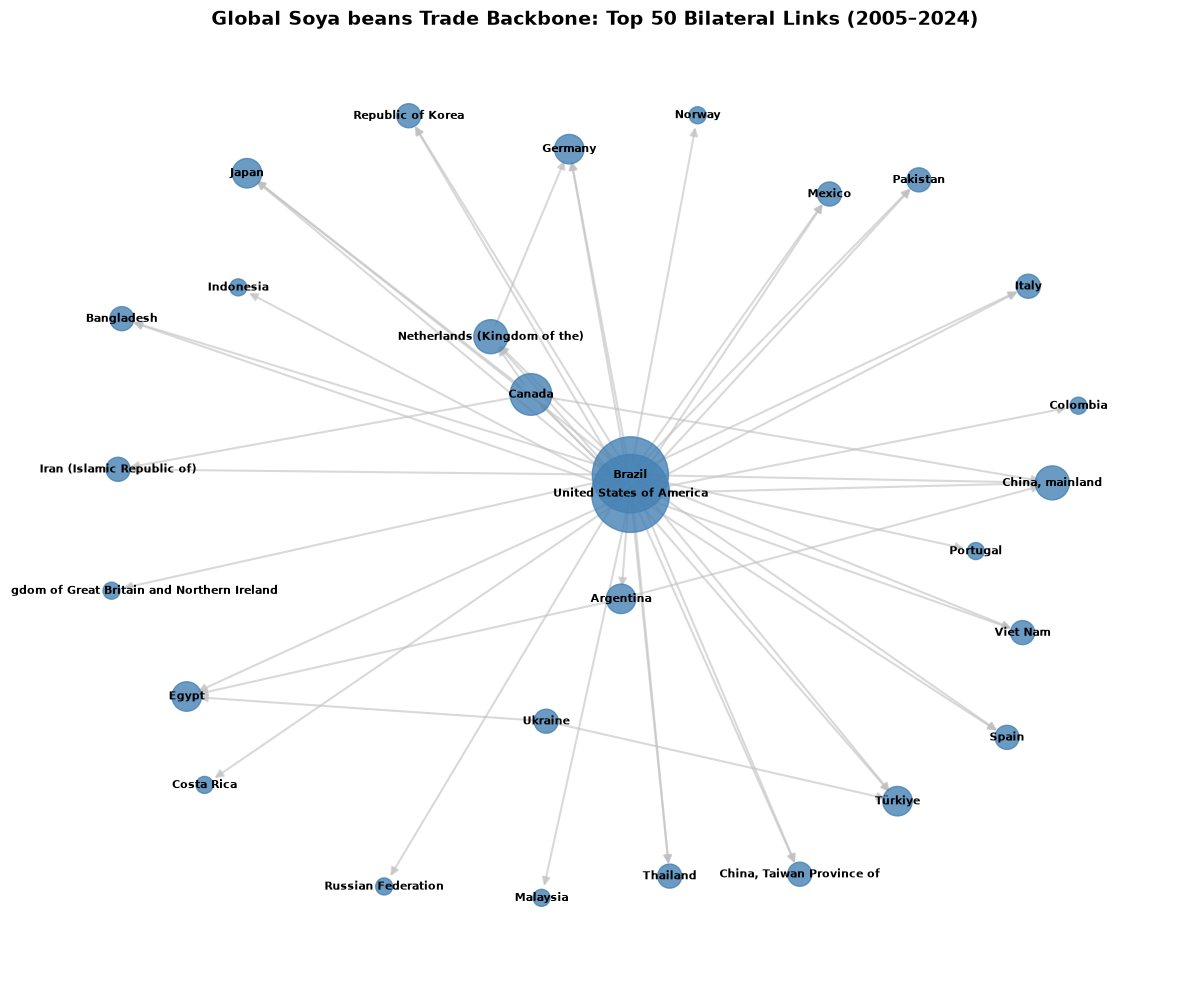

Saved: soya_beans_trade_backbone_2005_2024.png


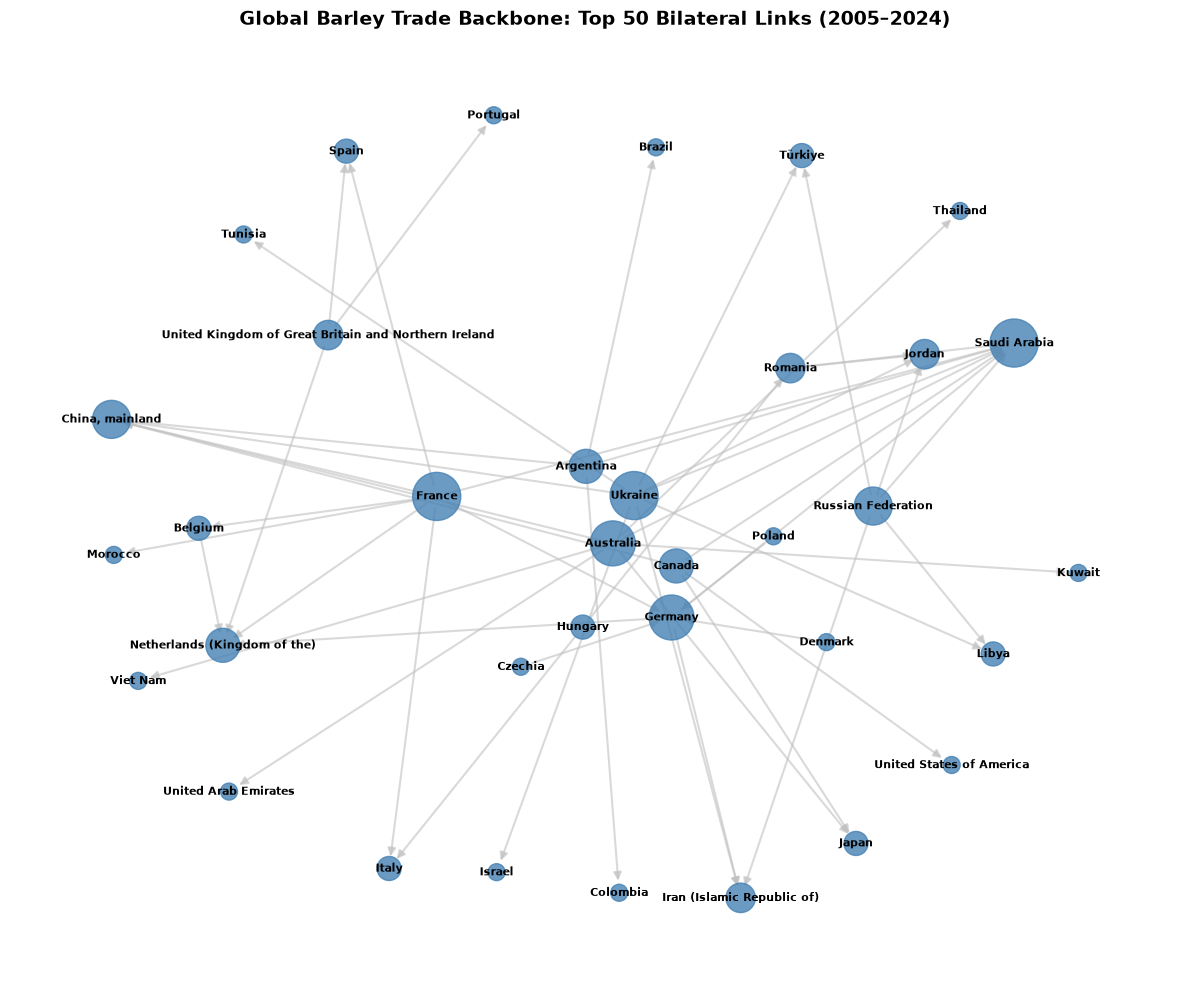

Saved: barley_trade_backbone_2005_2024.png


In [ ]:

# Filter dataset for the entire 2005-2024 timeframe
df_20yr = merged_df[
    (merged_df["Year"] >= 2005) & 
    (merged_df["Year"] <= 2024) & 
    (merged_df["final_weight"] > 0)
]

for commodity in core_staples:
    # 1. Aggregate total export quantity per bilateral pair across 2005-2024
    sub_df = (
        df_20yr[df_20yr["Item"] == commodity]
        .groupby(["Reporter Countries", "Partner Countries"], as_index=False)["final_weight"]
        .sum()
    )
    
    if sub_df.empty:
        print(f"Skipping {commodity}: No data found for 2005-2024")
        continue

    # 2. Extract Top 50 strongest bilateral trade routes over 20 years
    top_links = sub_df.sort_values(by="final_weight", ascending=False).head(50)
    
    # 3. Build Directed Graph
    G = nx.from_pandas_edgelist(
        top_links, 
        source="Reporter Countries", 
        target="Partner Countries", 
        edge_attr="final_weight", 
        create_using=nx.DiGraph()
    )
    
    # 4. Plot Backbone
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, k=0.5, seed=42)
    node_sizes = [v * 150 for v in dict(G.degree()).values()]
    
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#4682B4", alpha=0.8)
    nx.draw_networkx_edges(G, pos, edge_color="#C0C0C0", arrowsize=12, width=1.5, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")
    
    plt.title(f"Global {commodity} Trade Backbone: Top 50 Bilateral Links (2005–2024)", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    
    # 5. Save chart automatically using clean relative pathing
    clean_name = commodity.lower().replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
    save_file = OUTPUT_DIR / f"{clean_name}_trade_backbone_2005_2024.png"
    
    plt.savefig(save_file, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_file.name}")



### Systemic Supplier Centrality (Reversed PageRank)

Export volumes show which countries supply the largest quantities, but they do not necessarily indicate which suppliers are most important to the wider trade network. To capture this broader role, the following bar charts rank the top 10 suppliers for each commodity according to their Reversed PageRank scores.

For this measure, the direction of trade links is reversed before calculating PageRank. This allows a supplier’s importance to reflect the extent to which other countries rely on it for their imports. Countries with higher scores therefore occupy more influential positions within the network, and disruptions to these suppliers could affect multiple markets through connected trade relationships.


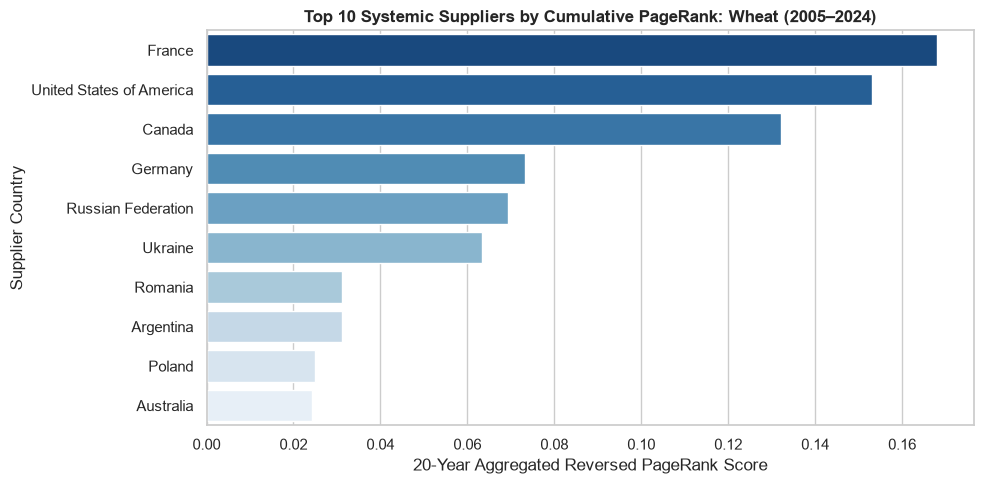

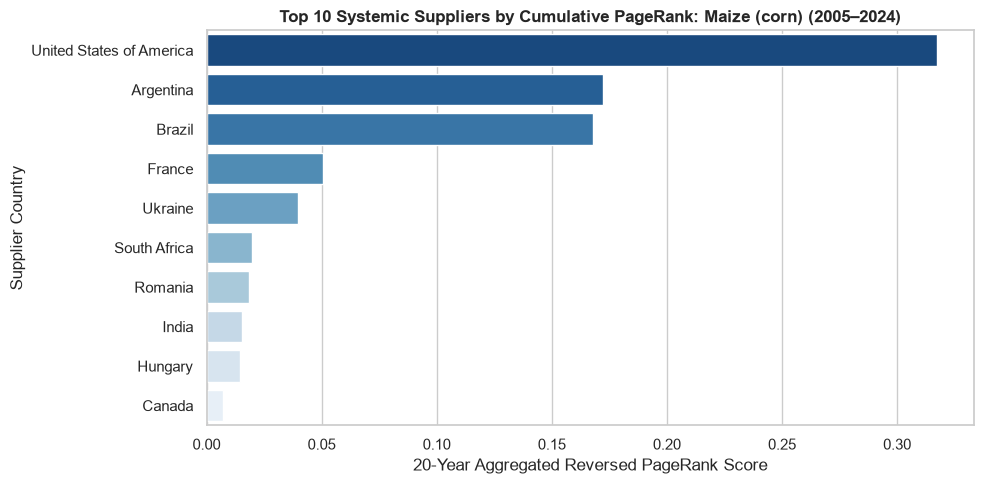

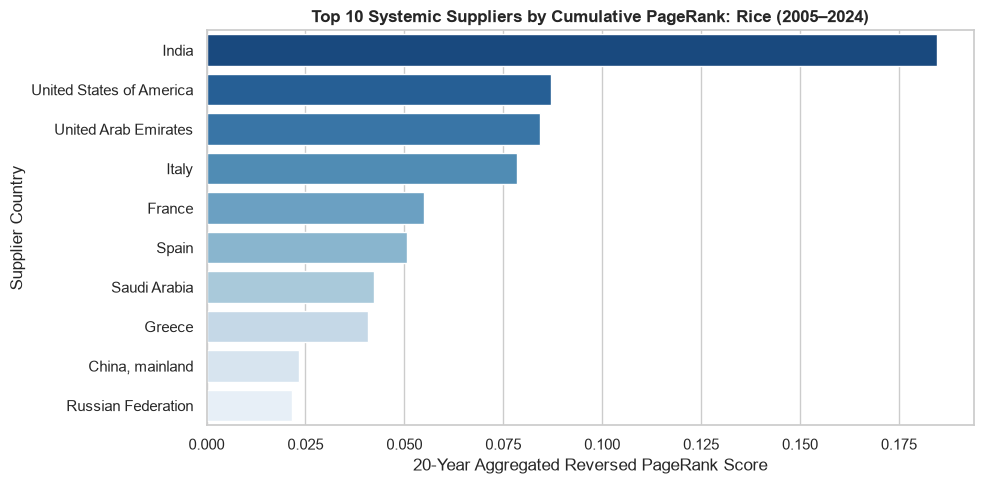

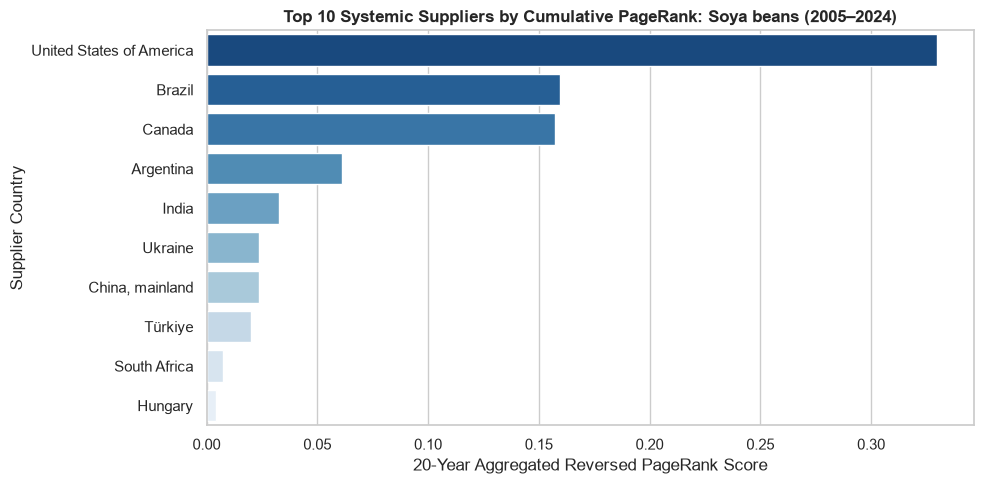

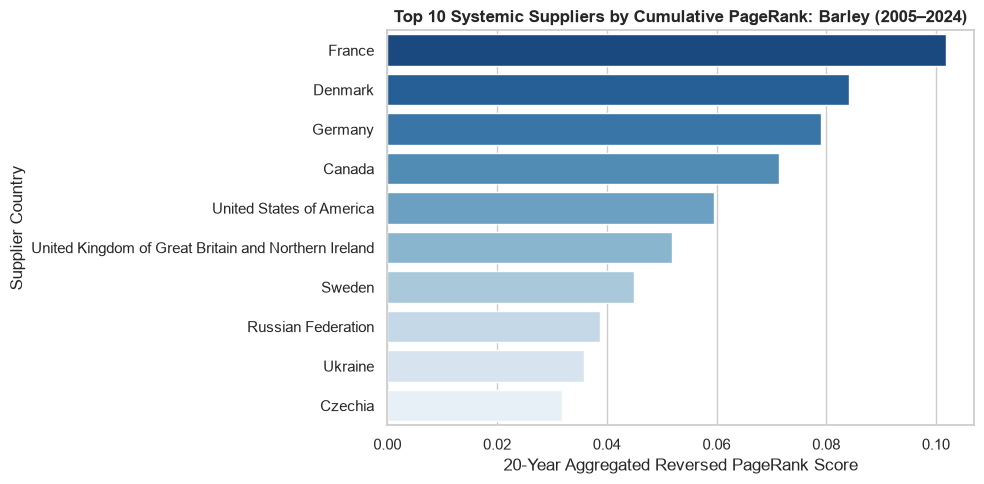

In [27]:
import seaborn as sns

# full timeframe
df_20yr = merged_df[
    (merged_df["Year"] >= 2005) & 
    (merged_df["Year"] <= 2024) & 
    (merged_df["final_weight"] > 0)
]

cumulative_pagerank_list = []

for commodity in core_staples:
    # Aggregate total bilateral trade 
    sub_df = (
        df_20yr[df_20yr["Item"] == commodity]
        .groupby(["Reporter Countries", "Partner Countries"], as_index=False)["final_weight"]
        .sum()
    )
    
    if sub_df.empty:
        continue

    # Build REVERSED graph to measure supplier centrality (Partner to Reporter)
    G = nx.from_pandas_edgelist(
        sub_df, 
        source="Partner Countries", 
        target="Reporter Countries", 
        edge_attr="final_weight", 
        create_using=nx.DiGraph()
    )
    
    # Calculate Reversed PageRank across the aggregated network
    pr_scores = nx.pagerank(G, weight="final_weight", alpha=0.85)
    
    for country, score in pr_scores.items():
        cumulative_pagerank_list.append({
            "Item": commodity,
            "Country": country,
            "PageRank_20yr": score
        })

cum_pr_df = pd.DataFrame(cumulative_pagerank_list)

# Render and save horizontal bar charts
sns.set_theme(style="whitegrid")

for commodity in core_staples:
    sub_pr = cum_pr_df[cum_pr_df["Item"] == commodity]
    top10 = sub_pr.sort_values(by="PageRank_20yr", ascending=False).head(10)
    
    plt.figure(figsize=(10, 5))
    
    sns.barplot(
        data=top10, 
        x="PageRank_20yr", 
        y="Country", 
        hue="Country", 
        palette="Blues_r", 
        legend=False
    )
    
    plt.title(f"Top 10 Systemic Suppliers by Cumulative PageRank: {commodity} (2005–2024)", fontsize=12, fontweight="bold")
    plt.xlabel("20-Year Aggregated Reversed PageRank Score")
    plt.ylabel("Supplier Country")
    plt.tight_layout()
    
    clean_name = commodity.lower().replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
    plt.savefig(OUTPUT_DIR / f"{clean_name}_pagerank_top10_cumulative_2005_2024.png", dpi=300, bbox_inches="tight")
    plt.show()




# Key Findings

# Overall Market Concentration (HHI Across Staples)

![HHI](historical_timelines/commodity_exporter_hhi_2005_2024.png)

## Exporter Market Concentration (2005–2024)

The Herfindahl-Hirschman Index (HHI) is used to compare how concentrated export supply is across the five staple commodities over the 2005–2024 period. Higher HHI values indicate that exports are concentrated among fewer countries, while lower values point to a more diversified supplier base. In this analysis, values above 0.25 are treated as relatively high concentration, whereas values below 0.15 indicate a more diversified market.

1. Rice, Highest and Most Variable Concentration: Rice records the highest HHI values for much of the study period, with concentration reaching above 0.85 at its peak before settling in the 0.35–0.60 range. This suggests a strong dependence on a relatively small number of exporters, leaving the market more exposed to export restrictions, production losses, or other disruptions affecting major Asian suppliers.

2. Soya Beans, Increasing Concentration: Soya beans show a clear upward trend in concentration, with HHI rising from approximately 0.33 in 2005 to almost 0.50 in 2024. The pattern points to a growing reliance on a small group of major exporters, particularly Brazil and the United States, which increasingly account for a large share of global trade.

3. Maize, Moderate Concentration: Maize remains within a relatively moderate HHI range of 0.20–0.35. Its trade structure is largely shaped by major exporters in the Western Hemisphere, although a number of regional suppliers provide some additional diversification.

4. Wheat and Barley, Lower Concentration: Wheat and barley generally remain below an HHI of 0.20 throughout the period. Their comparatively lower concentration indicates a broader distribution of export supply, with several countries contributing to the international market rather than one or two suppliers dominating trade.


#  Soya Beans Trade Architecture

### Soya Beans: Structural Concentration and Duopoly Risk

![Soya beans](historical_timelines/soya_beans_trade_backbone_2005_2024.png)

The network structure and centrality results for soya beans point to a highly concentrated global supply system. A relatively small number of exporters account for a large share of the major trade connections, creating substantial dependence on a few key suppliers.

1. Structural Backbone (2005–2024 Trade Corridors): The 50 strongest bilateral trade links form a tightly connected network centred mainly on Brazil and the United States. Both countries serve as major supply hubs, with significant export flows directed towards large markets in Asia, particularly Mainland China, as well as Europe. Argentina and Canada play smaller but still important roles within the network.

![Soya beans](historical_timelines/soya_beans_top15_timeline.png)

2. Systemic Centrality (Reversed PageRank): Brazil and the United States record substantially higher systemic centrality scores than other exporters. Their position in the network reflects the extent to which major importing countries depend on them for soya bean supplies. As a result, disruptions affecting either supplier could have wider effects across several downstream markets.

![Soya beans](historical_timelines/soya_beans_pagerank_top10_cumulative_2005_2024.png)

3. Timeline Trajectory: The annual PageRank results show a relatively close competition between the United States, Brazil and Canada for the most influential position in the network, with both generally falling within the 0.15–0.35 range. While the others remain considerably less central, with scores generally at or below 0.05.


# Wheat Trade Architecture

### Wheat: Network Diversification and Distributed Centrality


Wheat presents a different structure, with export influence spread across several major producing regions. Rather than depending heavily on one or two suppliers, the network contains multiple important exporters across North America, Europe, and the Black Sea region.

![Wheat](historical_timelines/wheat_trade_backbone_2005_2024.png)

1. Structural Backbone (Top 50 Bilateral Links): The cumulative 2005–2024 network is centred strongly on the United States, which appears in many of the largest bilateral trade connections. These major export routes link the US with markets across Latin America, Asia, Africa, and Europe, giving it a prominent position in the overall trade structure.


![wheat](historical_timelines/wheat_pagerank_top10_cumulative_2005_2024.png) 

2. Systemic Centrality (Reversed PageRank): The PageRank results present a more distributed picture of supplier importance. Although the United States accounts for many of the largest individual trade flows, France, Canada, Germany, Russia, and Ukraine also record relatively high centrality scores, ranging from approximately 0.06 to 0.17. This suggests that trade influence is not determined solely by export volume. These suppliers remain important because they are connected to a wider range of trading partners, including smaller and secondary markets that are not necessarily represented among the largest bilateral flows.

![wheat](historical_timelines/wheat_top15_timeline.png)

3. Timeline Trajectory: Annual PageRank scores show that the balance of influence changes over time. The United States had particularly high centrality in the earlier part of the study period, with scores above 0.25, while European and Black Sea exporters gained greater importance in subsequent years. By 2024, systemic influence was more evenly distributed across the major exporting countries.


# Rice Trade Architecture

## Rice: Regional Sub-Hubs and Shifting Centrality

Rice has one of the more varied trade structures in the dataset, with several regional hubs and noticeable changes in supplier importance over time.

![Rice](historical_timelines/rice_trade_backbone_2005_2024.png)

1. Structural Backbone (Top 50 Bilateral Links): The backbone network forms a multi-hub structure rather than being centred on a single exporter. The United States and Brazil account for several of the major bilateral corridors in the Americas, while European suppliers such as Italy and Spain connect strongly with markets across Europe and North Africa.

![Rice](historical_timelines/rice_pagerank_top10_cumulative_2005_2024.png)

2. Systemic Centrality (Reversed PageRank): India records the highest cumulative influence over the 2005–2024 period, with a score of approximately 0.18. It is followed by the United States (approximately 0.09), the United Arab Emirates (approximately 0.085), and Italy (approximately 0.08). The relatively high position of the UAE is notable because its role reflects the importance of intermediary and re-export hubs within the rice trade network, rather than simply the volume of rice it produces.

![Rice](historical_timelines/rice_top15_timeline.png)

3. Timeline Trajectory: Annual PageRank scores show considerable variation in supplier influence. India records particularly high levels of centrality in 2005 and 2018, when its score exceeded 0.25. During periods when India's centrality declined, suppliers such as Italy and the United States gained a larger share of network influence. This suggests that the distribution of systemic importance within the rice network can change substantially from year to year.





# Maize Trade Architecture

## Maize: Western Hemisphere Concentration and Uneven Dependency

Maize trade is concentrated among a relatively small group of exporters, with the United States, Argentina, and Brazil accounting for much of the network's supplier influence.

![Maize](historical_timelines/maize_corn_trade_backbone_2005_2024.png)

1. Structural Backbone (Top 50 Bilateral Links): The cumulative 2005–2024 network has a clear hub-and-spoke structure, with the United States occupying the most prominent position. It maintains major export connections with more than 40 destination countries across Latin America, Asia, and Europe, making it the main supplier within the backbone network.

![Maize](historical_timelines/maize_corn_pagerank_top10_cumulative_2005_2024.png)

2. Systemic Centrality (Reversed PageRank): The United States has the highest Reversed PageRank score at approximately 0.33, followed by Argentina (approximately 0.17) and Brazil (approximately 0.16). Together, these three countries account for more than 65% of the network's total supplier influence. France and Ukraine have lower but still noticeable centrality scores of around 0.05–0.06.

![Maize](historical_timelines/maize_corn_top15_timeline.png)

3. Timeline Trajectory: The United States remains the leading supplier in terms of PageRank centrality throughout most of the 2005–2024 period, with annual scores generally ranging from 0.23 to 0.38. Since around 2012, Brazil and Argentina have gradually increased their influence, narrowing the gap with the United States and giving the maize trade network a stronger South American presence.


# Barley Trade Architecture

## Barley: Multi-Centric Trade Structure and European Integration

Barley has one of the most decentralized trade structures in the dataset. Rather than being dominated by a single major exporter, the network is spread across several suppliers and regional trading groups, with particularly strong connections within Europe.

![Barley](historical_timelines/barley_trade_backbone_2005_2024.png)

1. Structural Backbone (Top 50 Bilateral Links): The backbone forms a dense, multi-centred network with no single country dominating the main trade corridors. Western European exporters, including France, Germany, and the United Kingdom, have strong connections with neighbouring markets. Other clusters link suppliers such as Ukraine, the Russian Federation, Argentina, and Australia with buyers in the Middle East and Asia.

![Barley](historical_timelines/barley_pagerank_top10_cumulative_2005_2024.png)

2. Systemic Centrality (Reversed PageRank): France has the highest cumulative systemic influence, with a score of approximately 0.10, followed by Denmark (approximately 0.085), Germany (approximately 0.08), Canada (approximately 0.075), and the United States (approximately 0.06). The relatively small differences between the leading suppliers indicate that systemic influence is distributed across a wider group of countries rather than concentrated in one or two exporters.

![Barley](historical_timelines/barley_top15_timeline.png)

3. Timeline Trajectory: Annual Reversed PageRank scores show considerable movement among the leading suppliers, with no country maintaining a clear lead throughout the full period. France and Denmark frequently alternate between the top positions, reaching scores of approximately 0.135–0.165 at their peaks. Other regional suppliers generally remain within the 0.03–0.10 range. This distribution provides multiple alternative sources of supply, which can reduce the effect of disruptions affecting any single exporter.


## Overall Summary and Key Findings

The analysis of global trade networks from 2005 to 2024 shows that the five staple commodities do not share the same pattern of supply concentration or systemic dependence. The combination of market concentration, trade-network structure, and supplier centrality provides a more complete picture of how global food supply is organised and where potential points of vulnerability lie.

### 1. Global Food Supply Is Unevenly Distributed

The HHI results show clear differences in exporter concentration across the five commodities. Rice has the highest and most variable concentration, with HHI values reaching above 0.85 during the study period. Soya beans also show a sustained increase in concentration, rising from approximately 0.33 in 2005 to almost 0.50 in 2024. Maize remains moderately concentrated, while wheat and barley maintain comparatively lower levels of concentration.

This suggests that food-supply exposure is commodity-specific. A disruption to a major exporter would not have the same potential consequences across all five markets because the underlying supplier structures are different.

### 2. Export Volume and Systemic Importance Are Not the Same

One of the clearest findings from the network analysis is that the countries responsible for the largest individual trade flows are not always the countries with the greatest systemic importance.

The backbone networks identify the largest and most persistent bilateral trade corridors, while Reversed PageRank captures how important a supplier is within the wider network of trading relationships. This distinction is particularly clear in the wheat network, where the United States accounts for many major bilateral flows, but France, Canada, Germany, Russia, and Ukraine also maintain substantial systemic influence.

This means that assessing food-security risk purely through export volumes can overlook suppliers that play important roles across a wider set of trading relationships.

### 3. Soya Beans Represent the Strongest Case of Supplier Dependence

Among the five commodities, soya beans show one of the clearest examples of concentrated systemic influence. The backbone network is centred largely on Brazil and the United States, while the Reversed PageRank results place both countries well ahead of most other exporters.

The concentration has also increased over time, with the HHI approaching 0.50 by 2024. Taken together, these results point to a trade system in which a relatively small number of suppliers have a large influence over global availability. This makes soya beans particularly sensitive to production shocks, trade restrictions, or other disruptions affecting its main exporting countries.

### 4. Wheat Shows a More Distributed Supply Structure

Wheat presents a contrasting pattern. Its backbone network connects several major exporting regions, including North America, Western Europe, and the Black Sea region. France, the United States, Canada, Germany, Russia, and Ukraine all contribute meaningful levels of systemic influence.

The gradual distribution of PageRank scores across these countries indicates that wheat does not depend on a single dominant supplier to the same extent as some of the other commodities. Although individual exporters remain important, the presence of several major supply centres provides a broader base from which international markets can source wheat.

### 5. Rice Combines Concentration With Changing Supplier Influence

Rice displays a different form of vulnerability. Its trade network contains several regional hubs, but the HHI results show much higher levels of exporter concentration than for wheat or barley. India is the most influential supplier across the full study period, although its annual PageRank scores vary substantially over time.

The importance of the United Arab Emirates is also notable. Its position in the network illustrates that systemic importance is not limited to countries that produce the commodity themselves. Re-export and intermediary hubs can become important links between suppliers and final markets, meaning that disruptions at these nodes can affect trade beyond their own domestic production.

### 6. Maize Is Concentrated Around Three Major Suppliers

Maize falls between the highly concentrated structure observed for rice and soya beans and the more distributed structure of wheat and barley. The United States remains the dominant supplier in both the backbone and PageRank results, while Argentina and Brazil have become increasingly important.

By 2024, these three countries account for more than 65% of total supplier influence in the network. The growing role of Brazil and Argentina since around 2012 suggests that maize supply is becoming less dependent on the United States alone, although the overall network remains concentrated among a small group of exporters.

### 7. Barley Has the Most Distributed Network Structure

Barley stands out as the most decentralised of the five commodities. Its backbone network contains several regional clusters, particularly across Europe, while suppliers in the Black Sea region, North America, and the Southern Hemisphere provide additional connections.

The relatively small differences between the leading Reversed PageRank scores further support this finding. France, Denmark, Germany, Canada, and the United States all occupy important positions without one supplier consistently dominating the network. This broader distribution creates more opportunities for markets to source from alternative suppliers when disruptions occur.

### Overall Finding

Taken together, the results show that global food-security risk is shaped not only by how much a country exports, but also by how that country is positioned within the wider trade network.

Rice and soya beans present the strongest concentration concerns, although for different reasons. Rice combines high exporter concentration with substantial changes in supplier influence, while soya beans show a more persistent concentration around Brazil and the United States. Maize also depends heavily on a small group of exporters, but the growing contribution of Brazil and Argentina provides some diversification. Wheat and barley have more distributed supplier structures, with multiple countries contributing to global trade and systemic influence.

The comparison therefore highlights three distinct dimensions of food-supply vulnerability:

1. Market concentration: how much global supply is controlled by a small number of exporters.
2. Network centrality: how important a supplier is within the wider structure of international trade.
3. Network diversification: how widely supply is distributed across countries and regional trade corridors.

Considering these dimensions together provides a stronger assessment of global food-supply resilience than export volumes alone. A country may not be the largest exporter, yet still occupy a strategically important position because of the number or importance of markets that depend on it. Conversely, a highly concentrated export market may remain relatively resilient if alternative suppliers are well connected and able to absorb disruptions.

### Final Takeaway

The 2005–2024 trade networks show that there is no single global food-supply structure. Each commodity has developed its own combination of concentration, regional integration, and supplier dependence. The most important implication is therefore not simply which countries export the most, but which countries the global system has the fewest practical alternatives to.

Identifying these critical suppliers and trade structures provides a clearer basis for understanding where future disruptions could propagate across international food markets and where greater diversification of supply may strengthen resilience.
